# Anomaly Detection

Anomaly detection identifies data points that deviate significantly from
the expected pattern. This notebook covers statistical, distance-based,
and model-based approaches with hands-on implementations.

**Prerequisites:**
```bash
pip install numpy matplotlib scikit-learn scipy pandas
```

📺 **Video Lecture:** [https://youtu.be/wOb5Il6zMqI](https://youtu.be/wOb5Il6zMqI)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
np.random.seed(42)

print('All libraries loaded!')

All libraries loaded!


## 1. Creating a Dataset with Known Anomalies

We'll generate a dataset with clear normal patterns plus injected anomalies,
so we can validate our detection methods.

Dataset: 308 points (300 normal, 8 anomalies)


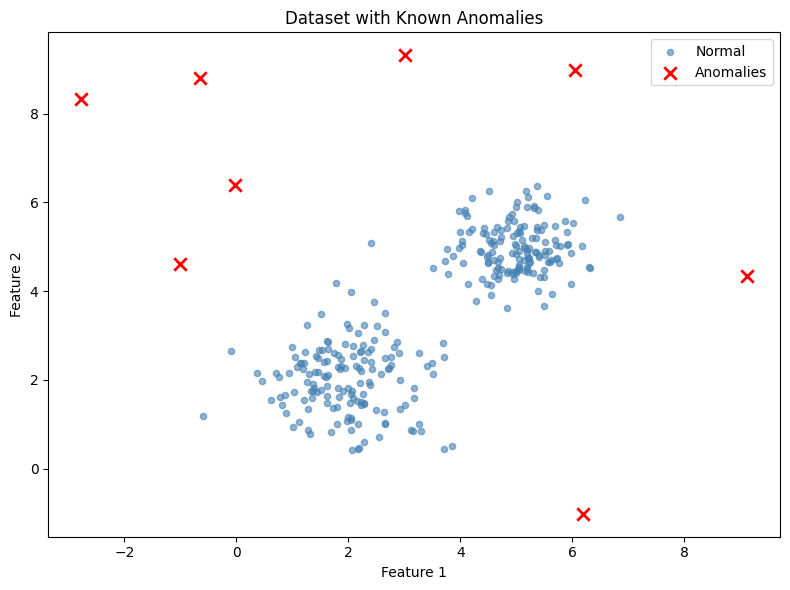

In [3]:
# Generate 2D data: a main cluster + a secondary cluster + anomalies
n_normal = 300
n_anomalies = 15

# Normal data: two Gaussian clusters
cluster1 = np.random.randn(n_normal // 2, 2) * 0.8 + np.array([2, 2])
cluster2 = np.random.randn(n_normal // 2, 2) * 0.6 + np.array([5, 5])
X_normal = np.vstack([cluster1, cluster2])

# Anomalies: scattered far from clusters
X_anomalies = np.random.uniform(low=-3, high=10, size=(n_anomalies, 2))
# Ensure anomalies are actually far from clusters
X_anomalies = X_anomalies[np.min([
    np.linalg.norm(X_anomalies - np.array([2,2]), axis=1),
    np.linalg.norm(X_anomalies - np.array([5,5]), axis=1)
], axis=0) > 3]

# Combine
X = np.vstack([X_normal, X_anomalies])
y_true = np.concatenate([np.zeros(len(X_normal)), np.ones(len(X_anomalies))])

print(f'Dataset: {len(X)} points ({len(X_normal)} normal, {len(X_anomalies)} anomalies)')

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_normal[:, 0], X_normal[:, 1], c='steelblue', s=20, alpha=0.6, label='Normal')
ax.scatter(X_anomalies[:, 0], X_anomalies[:, 1], c='red', s=80, marker='x',
           linewidths=2, label='Anomalies')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.set_title('Dataset with Known Anomalies'); ax.legend()
plt.tight_layout(); plt.show()

## 2. Statistical Methods

### Z-Score Method
Flag points more than $k$ standard deviations from the mean.
Simple and fast, but assumes Gaussian distribution.

In [4]:
def z_score_detection(X, threshold=3.0):
    """
    Detect anomalies using Z-scores.
    A point is anomalous if ANY feature has |z| > threshold.
    """
    z_scores = np.abs(stats.zscore(X))
    is_anomaly = (z_scores > threshold).any(axis=1)
    return is_anomaly

# Apply Z-score detection
z_anomalies = z_score_detection(X, threshold=2.5)
print(f'Z-score method detected {z_anomalies.sum()} anomalies')

# IQR (Interquartile Range) method — more robust to outliers in the data itself
def iqr_detection(X, multiplier=1.5):
    """Detect outliers using the IQR method (box plot rule)."""
    Q1 = np.percentile(X, 25, axis=0)
    Q3 = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    is_anomaly = ((X < lower) | (X > upper)).any(axis=1)
    return is_anomaly

iqr_anomalies = iqr_detection(X, multiplier=2.0)
print(f'IQR method detected {iqr_anomalies.sum()} anomalies')

Z-score method detected 7 anomalies
IQR method detected 0 anomalies


## 3. Mahalanobis Distance

Unlike Euclidean distance, Mahalanobis distance accounts for correlations
between features. It measures how many standard deviations a point is
from the center of the distribution.

Mahalanobis method detected 8 anomalies


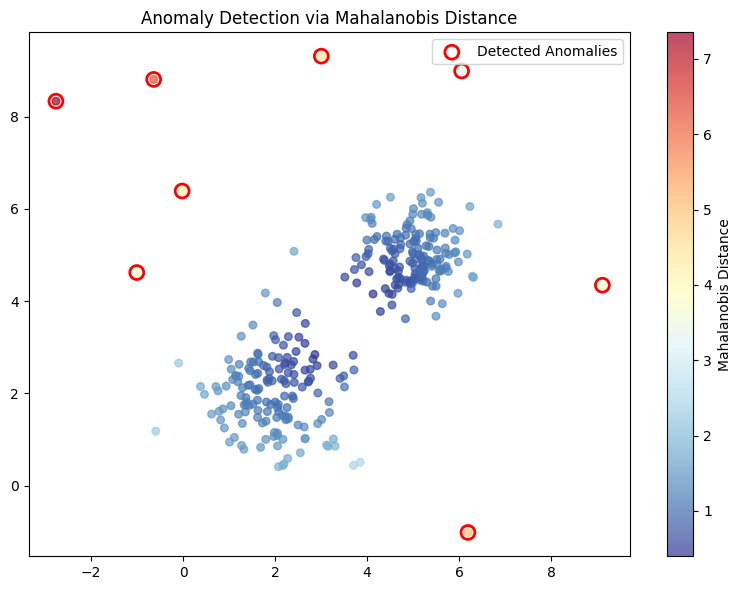

In [5]:
def mahalanobis_detection(X, threshold_percentile=97.5):
    """
    Detect anomalies using Mahalanobis distance.
    Uses chi-squared distribution for threshold.
    """
    mean = X.mean(axis=0)
    cov = np.cov(X.T)
    cov_inv = np.linalg.inv(cov)
    
    # Compute Mahalanobis distance for each point
    diffs = X - mean
    distances = np.sqrt(np.sum(diffs @ cov_inv * diffs, axis=1))
    
    # Threshold using chi-squared distribution
    threshold = np.sqrt(stats.chi2.ppf(threshold_percentile / 100, df=X.shape[1]))
    is_anomaly = distances > threshold
    
    return is_anomaly, distances

mah_anomalies, mah_distances = mahalanobis_detection(X)
print(f'Mahalanobis method detected {mah_anomalies.sum()} anomalies')

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=mah_distances, cmap='RdYlBu_r',
                    s=30, alpha=0.7)
ax.scatter(X[mah_anomalies, 0], X[mah_anomalies, 1], facecolors='none',
          edgecolors='red', s=100, linewidths=2, label='Detected Anomalies')
plt.colorbar(scatter, label='Mahalanobis Distance')
ax.set_title('Anomaly Detection via Mahalanobis Distance')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Isolation Forest

**Key insight**: Anomalies are easier to isolate. Random splits require
fewer cuts to separate anomalies from the rest.

- Builds an ensemble of random trees
- Anomalies have shorter average path lengths
- No assumptions about data distribution

Isolation Forest detected 16 anomalies


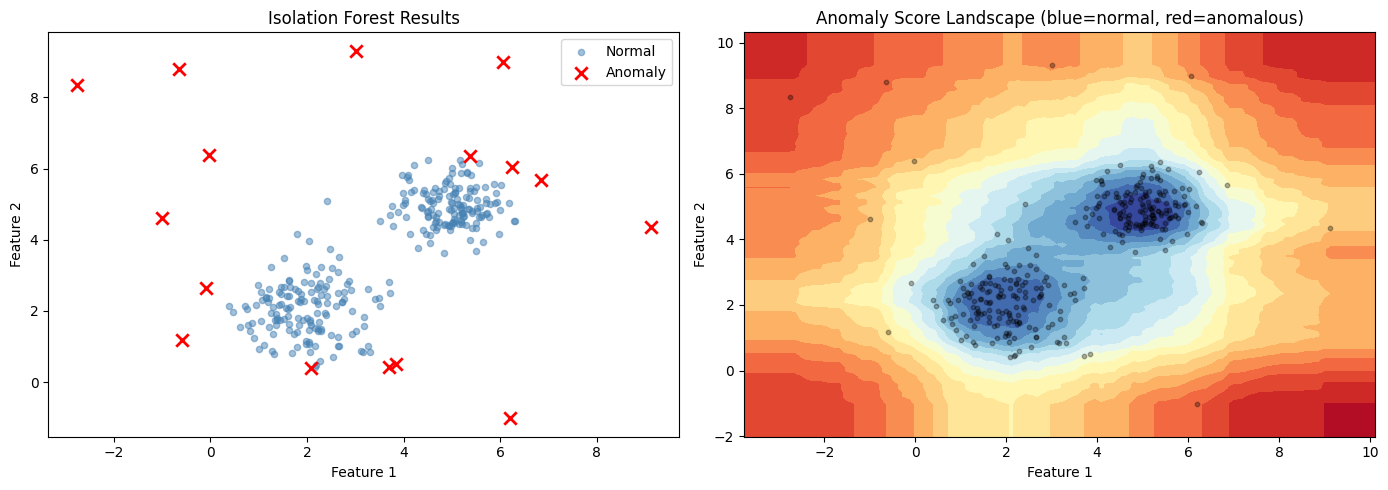

In [6]:
# Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05,
                             random_state=42)
iso_predictions = iso_forest.fit_predict(X)
iso_anomalies = iso_predictions == -1
iso_scores = iso_forest.decision_function(X)  # anomaly score

print(f'Isolation Forest detected {iso_anomalies.sum()} anomalies')

# Visualize decision boundary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Detected anomalies
axes[0].scatter(X[~iso_anomalies, 0], X[~iso_anomalies, 1],
               c='steelblue', s=20, alpha=0.5, label='Normal')
axes[0].scatter(X[iso_anomalies, 0], X[iso_anomalies, 1],
               c='red', s=80, marker='x', linewidths=2, label='Anomaly')
axes[0].set_title('Isolation Forest Results'); axes[0].legend()

# Plot 2: Anomaly scores heatmap
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100))
Z = iso_forest.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, levels=20, cmap='RdYlBu')
axes[1].scatter(X[:, 0], X[:, 1], c='black', s=10, alpha=0.3)
axes[1].set_title('Anomaly Score Landscape (blue=normal, red=anomalous)')

for ax in axes:
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout(); plt.show()

## 5. Local Outlier Factor (LOF)

LOF compares the local density of a point to its neighbors.
A point is anomalous if its density is much lower than its neighbors'
density. This handles datasets with varying cluster densities.

LOF detected 16 anomalies


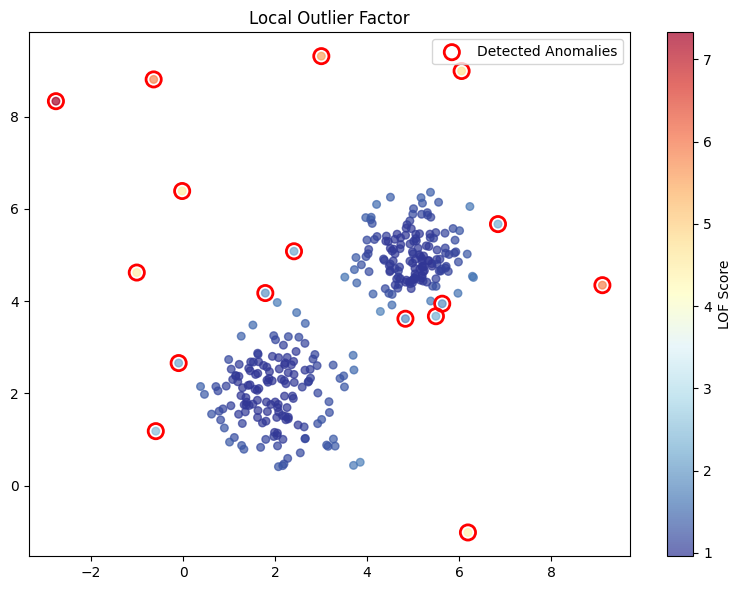

In [7]:
# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_predictions = lof.fit_predict(X)
lof_anomalies = lof_predictions == -1
lof_scores = -lof.negative_outlier_factor_  # higher = more anomalous

print(f'LOF detected {lof_anomalies.sum()} anomalies')

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=lof_scores, cmap='RdYlBu_r',
                    s=30, alpha=0.7)
ax.scatter(X[lof_anomalies, 0], X[lof_anomalies, 1], facecolors='none',
          edgecolors='red', s=120, linewidths=2, label='Detected Anomalies')
plt.colorbar(scatter, label='LOF Score')
ax.set_title('Local Outlier Factor'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Time Series Anomaly Detection

In time series, anomalies can be:
- **Point anomalies**: single unusual values
- **Contextual anomalies**: normal values in an unusual context
- **Collective anomalies**: unusual subsequences

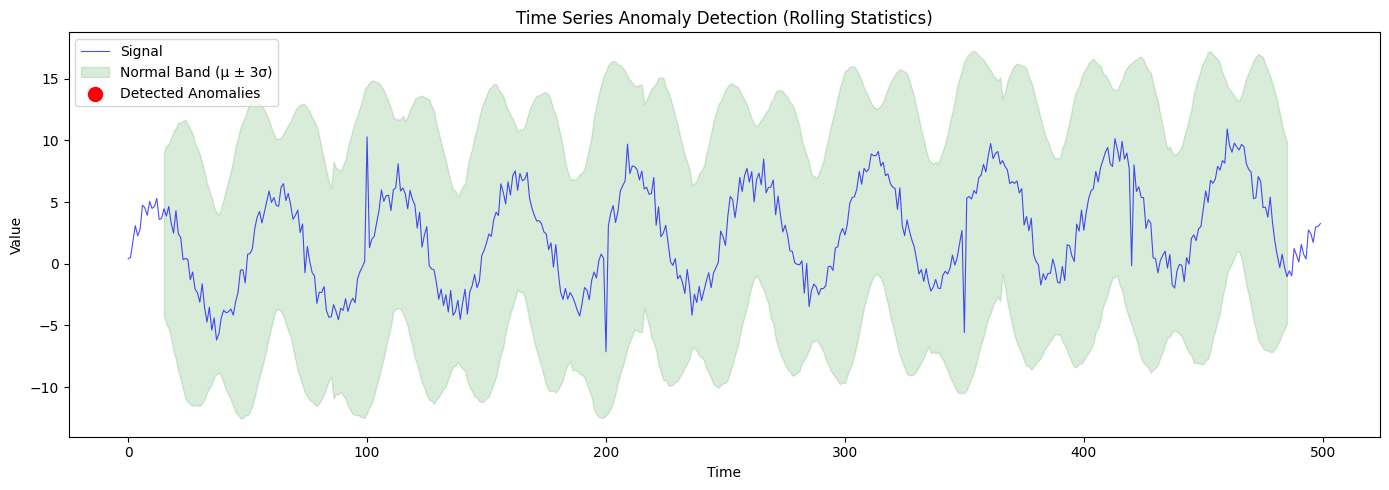

Detected 0 anomalous points


In [8]:
# Generate time series with anomalies
np.random.seed(42)
t = np.arange(500)
# Normal pattern: trend + seasonality + noise
signal = 0.01 * t + 5 * np.sin(2 * np.pi * t / 50) + np.random.randn(500) * 0.8

# Inject anomalies
anomaly_indices = [100, 200, 350, 420]
for idx in anomaly_indices:
    signal[idx] += np.random.choice([-1, 1]) * np.random.uniform(8, 12)

# Detection: rolling statistics method
window = 30
rolling_mean = pd.Series(signal).rolling(window, center=True).mean()
rolling_std = pd.Series(signal).rolling(window, center=True).std()
upper_bound = rolling_mean + 3 * rolling_std
lower_bound = rolling_mean - 3 * rolling_std
ts_anomalies = (signal > upper_bound) | (signal < lower_bound)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t, signal, 'b-', alpha=0.7, linewidth=0.8, label='Signal')
ax.fill_between(t, lower_bound, upper_bound, alpha=0.15, color='green',
               label='Normal Band (μ ± 3σ)')
ax.scatter(t[ts_anomalies], signal[ts_anomalies], c='red', s=100,
          zorder=5, label='Detected Anomalies', marker='o')
ax.set_xlabel('Time'); ax.set_ylabel('Value')
ax.set_title('Time Series Anomaly Detection (Rolling Statistics)')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
print(f'Detected {ts_anomalies.sum()} anomalous points')

## 7. Comparing Methods

Let's evaluate all methods on our labeled dataset.

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

methods = {
    'Z-Score': z_anomalies,
    'IQR': iqr_anomalies,
    'Mahalanobis': mah_anomalies,
    'Isolation Forest': iso_anomalies,
    'LOF': lof_anomalies,
}

print(f"{'Method':<18} {'Detected':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
print('-' * 58)
for name, preds in methods.items():
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)
    print(f'{name:<18} {preds.sum():<10} {p:<10.3f} {r:<10.3f} {f1:<10.3f}')

print('\nNote: Results depend on data characteristics and hyperparameters.')
print('In practice, combine methods and validate with domain expertise.')

Method             Detected   Precision  Recall     F1        
----------------------------------------------------------
Z-Score            7          1.000      0.875      0.933     
IQR                0          0.000      0.000      0.000     
Mahalanobis        8          1.000      1.000      1.000     
Isolation Forest   16         0.500      1.000      0.667     
LOF                16         0.500      1.000      0.667     

Note: Results depend on data characteristics and hyperparameters.
In practice, combine methods and validate with domain expertise.


## 8. Interview Takeaways

**Key points for interviews:**

- **Statistical methods** (Z-score, IQR): simple, fast, assume distribution properties
- **Mahalanobis distance**: accounts for feature correlations, good for multivariate data
- **Isolation Forest**: tree-based, no distribution assumptions, scales well
- **LOF**: density-based, handles varying densities, good for local anomalies
- **Time series**: use rolling windows, seasonal decomposition, or autoencoders
- **Challenges**: label scarcity, high dimensionality, concept drift
- **Evaluation**: precision/recall tradeoff is critical (false alarms vs missed anomalies)
- **Real-world**: fraud detection, network intrusion, predictive maintenance, healthcare

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>